# DermAI: Skin Condition Classification Platform


## Installs & Imports

In [1]:
# Installs and Imports
!pip install google-cloud-storage pillow scikit-learn tensorflow matplotlib tqdm

import os
import pandas as pd
import numpy as np
import io
import ast
import shutil
import random
from PIL import Image
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

## Data Access & Loading

In [2]:
# Authenticate + load data
from google.colab import auth
from google.cloud import storage

auth.authenticate_user()

client = storage.Client(project="dx-scin-public")
bucket = client.bucket("dx-scin-public-data")

def load_csv(path):
    blob = bucket.blob(path)
    return pd.read_csv(io.BytesIO(blob.download_as_string()))

cases = load_csv("dataset/scin_cases.csv")
labels = load_csv("dataset/scin_labels.csv")

df = pd.merge(cases, labels, on="case_id")

print("Dataset size:", df.shape)

Dataset size: (5033, 73)


In [3]:
# Extract labels
def extract_label(label):
    try:
        if pd.isna(label):
            return None

        label_dict = ast.literal_eval(label)

        if not isinstance(label_dict, dict) or len(label_dict) == 0:
            return None

        return max(label_dict, key=label_dict.get)

    except:
        return None

df["label"] = df["weighted_skin_condition_label"].apply(extract_label)

## Data Cleaning

In [4]:
# Clean Data
# Remove classes with less than 100
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(str)
df = df.reset_index(drop=True)

counts = df["label"].value_counts()
valid_classes = counts[counts >= 100].index

df = df[df["label"].isin(valid_classes)].reset_index(drop=True)

print("New class distribution:")
print(df["label"].value_counts())

New class distribution:
label
Eczema                         488
Allergic Contact Dermatitis    270
Urticaria                      214
Insect Bite                    185
Folliculitis                   142
Psoriasis                      109
Name: count, dtype: int64


In [5]:
# All image paths
image_cols = ["image_1_path", "image_2_path", "image_3_path"]

dfs = []

for col in image_cols:
    temp = df[[col, "case_id", "label"]].copy()
    temp.columns = ["image_path", "case_id", "label"]
    temp = temp.dropna()
    dfs.append(temp)

df = pd.concat(dfs).reset_index(drop=True)

print("Image-level dataset:", df.shape)

Image-level dataset: (3052, 3)


## Train-Test Split

In [6]:
# Train / Test Split
# Split by case id

# Unique patients
unique_cases = df["case_id"].unique()

train_cases, test_cases = train_test_split(
    unique_cases,
    test_size=0.2,
    random_state=42
)

train_df = df[df["case_id"].isin(train_cases)].reset_index(drop=True)
test_df = df[df["case_id"].isin(test_cases)].reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (2455, 3)
Test: (597, 3)


## Image Download Pipeline

In [7]:
# Download images
base_dir = "data"
train_path = os.path.join(base_dir, "train")
test_path = os.path.join(base_dir, "test")

os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

def save_image(row, split):
    try:
        filename = row["image_path"].split("/")[-1]
        label = row["label"]

        save_dir = os.path.join(base_dir, split, label)
        os.makedirs(save_dir, exist_ok=True)

        local_path = os.path.join(save_dir, filename)

        if not os.path.exists(local_path):
            bucket.blob(row["image_path"]).download_to_filename(local_path)

    except:
        pass


for _, row in train_df.iterrows():
    save_image(row, "train")

for _, row in test_df.iterrows():
    save_image(row, "test")

## Exploratory Data Analysis (EDA)

In [8]:
# Class distribution
print("\nTrain distribution:")
print(train_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Train distribution:
label
Eczema                         827
Allergic Contact Dermatitis    500
Urticaria                      366
Insect Bite                    331
Folliculitis                   258
Psoriasis                      173
Name: count, dtype: int64

Test distribution:
label
Eczema                         252
Allergic Contact Dermatitis     90
Urticaria                       76
Insect Bite                     70
Psoriasis                       61
Folliculitis                    48
Name: count, dtype: int64


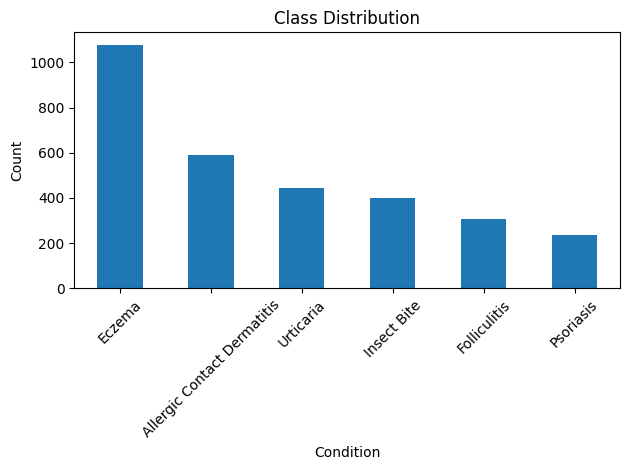

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save as PDF
plt.savefig("class_distribution.png", format="pdf", bbox_inches="tight")

plt.show()

In [10]:
# Balancing dataset (oversampling non eczema)
balanced_base = "data_balanced/train"
os.makedirs(balanced_base, exist_ok=True)

#  Target
TARGET_SIZE = 650

for label in train_df["label"].unique():

    class_df = train_df[train_df["label"] == label]
    class_dir = os.path.join(balanced_base, label)
    os.makedirs(class_dir, exist_ok=True)

    #  KEEP ECZEMA AS IS
    if label == "Eczema":
        sampled_df = class_df.copy()
    else:
        # oversample ONLY non-eczema
        sampled_df = class_df.sample(
            n=min(TARGET_SIZE, len(class_df) * 3),
            replace=True,
            random_state=42
        )

    for _, row in sampled_df.iterrows():
        filename = row["image_path"].split("/")[-1]
        src = os.path.join("data/train", label, filename)

        if os.path.exists(src):
            #  prevent overwrite
            new_filename = f"{random.randint(0,999999)}_{filename}"
            dst = os.path.join(class_dir, new_filename)
            shutil.copy(src, dst)

## TensorFlow Dataset Pipeline

In [11]:
# Load data as TensorFlow datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data_balanced/train",
    image_size=(224,224),
    batch_size=32,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Save class names BEFORE caching
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

Found 3946 files belonging to 6 classes.
Found 597 files belonging to 6 classes.
Classes: ['Allergic Contact Dermatitis', 'Eczema', 'Folliculitis', 'Insect Bite', 'Psoriasis', 'Urticaria']


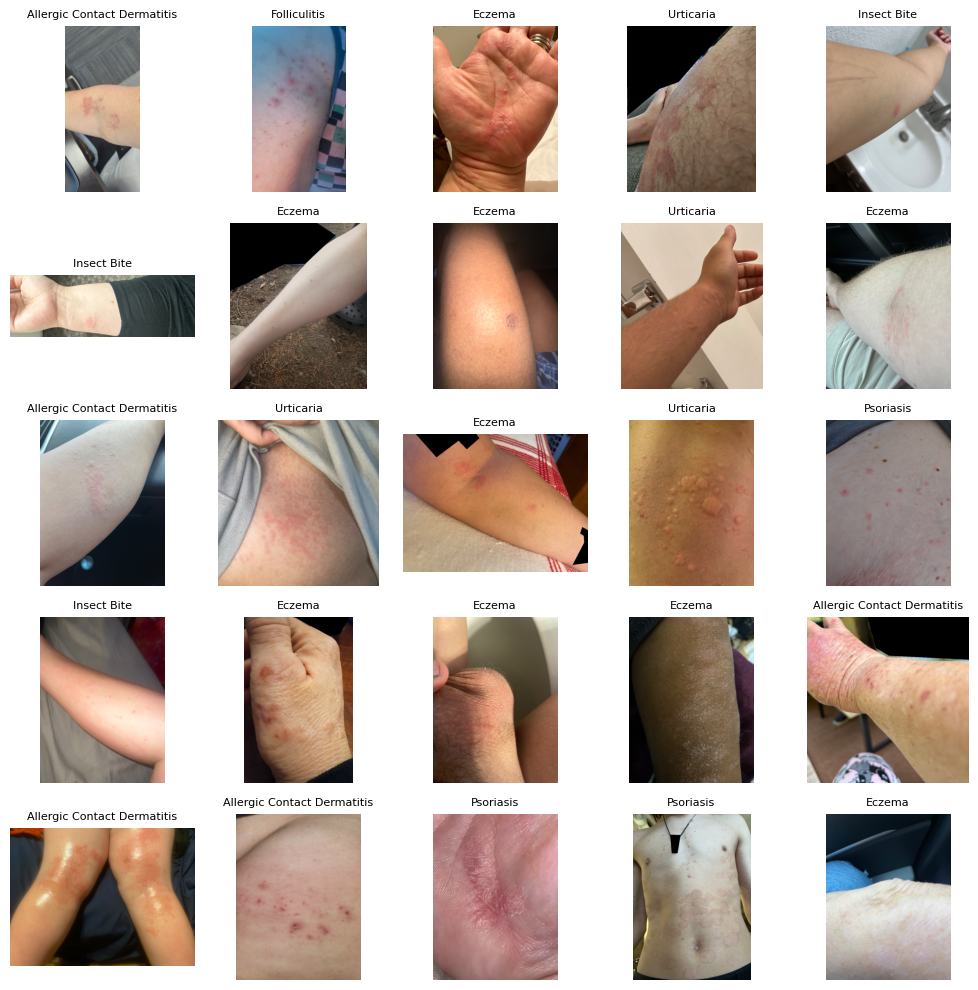

In [12]:
# Visualize Sample Images
sample_df = train_df.sample(25)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(
        os.path.join("data/train", row["label"], row["image_path"].split("/")[-1])
    )

    plt.subplot(5,5,i+1)
    plt.imshow(img)
    plt.title(row["label"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Image dimensions check
def get_size(path):
    try:
        img = Image.open(path)
        return img.size
    except:
        return None

# Sample
sample_paths = train_df["image_path"].sample(500)

sizes = []

for p in sample_paths:
    try:
        img = bucket.blob(p)
        img_bytes = img.download_as_bytes()
        image = Image.open(io.BytesIO(img_bytes))
        sizes.append(image.size)
    except:
        continue

print(pd.Series(sizes).value_counts().head())

(810, 1080)    247
(1080, 810)     43
(813, 1080)      9
(486, 1080)      4
(608, 1080)      4
Name: count, dtype: int64


## Pre-Processing

In [14]:
# Class Weights

# Create mapping from class names
label_to_index = {name: i for i, name in enumerate(class_names)}

# Use OVERSAMPLED train_df
y_train = train_df["label"].map(label_to_index).values

# Compute balanced weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))

print("Original weights:", class_weight_dict)

# Soften weights
class_weight_dict = {k: v**0.5 for k, v in class_weight_dict.items()}

print("Final adjusted weights:", class_weight_dict)

Original weights: {np.int64(0): np.float64(0.8183333333333334), np.int64(1): np.float64(0.4947601773478436), np.int64(2): np.float64(1.5859173126614987), np.int64(3): np.float64(1.2361530715005036), np.int64(4): np.float64(2.3651252408477843), np.int64(5): np.float64(1.1179417122040072)}
Final adjusted weights: {np.int64(0): np.float64(0.9046177830074608), np.int64(1): np.float64(0.703391908787586), np.int64(2): np.float64(1.2593320899038103), np.int64(3): np.float64(1.1118242089019754), np.int64(4): np.float64(1.5378963686958182), np.int64(5): np.float64(1.0573276276556889)}


In [ ]:
# Label econder
le = LabelEncoder()
le.fit(df["label"])

y_train = le.transform(train_df["label"])
y_test = le.transform(test_df["label"])

In [16]:
# Augmentation (train dataset)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.05),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def augment(image, label):
    return data_augmentation(image), label

train_ds = train_ds.map(augment)

In [17]:
# DenseNet preprocessing
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

## Model Architecture

In [18]:
# Model
from tensorflow.keras import layers, models

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,574 (27.37 MB)

 Trainable params: 775,430 (2.96 MB)

 Non-trainable params: 6,398,144 (24.41 MB)

In [19]:
# Fine tuning
for layer in base_model.layers:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training

In [21]:
# Training
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    callbacks=[lr_scheduler],
    class_weight=class_weight_dict
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 51s 408ms/step - accuracy: 0.9506 - loss: 0.1489 - val_accuracy: 0.3819 - val_loss: 2.1718 - learning_rate: 3.0000e-05
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 50s 404ms/step - accuracy: 0.9584 - loss: 0.1335 - val_accuracy: 0.4003 - val_loss: 2.2278 - learning_rate: 3.0000e-05
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 50s 404ms/step - accuracy: 0.9595 - loss: 0.1261 - val_accuracy: 0.4003 - val_loss: 2.2650 - learning_rate: 3.0000e-05
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9665 - loss: 0.1117
Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 414ms/step - accuracy: 0.9686 - loss: 0.1042 - val_accuracy: 0.3987 - val_loss: 2.3566 - learning_rate: 3.0000e-05
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 51s 409ms/step - accuracy: 0.9703 - loss: 0.0965 - val_accuracy: 0.3953 - val_loss: 2.3627 - learning_rate: 9.0000e-06
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 412ms/st

## Evaluation

In [22]:
# Error analysis
from sklearn.metrics import classification_report

# Get class names
target = class_names

# Collect true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print report
print(classification_report(y_true, y_pred, target_names=target))

19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 850ms/step
                             precision    recall  f1-score   support

Allergic Contact Dermatitis       0.21      0.21      0.21        90
                     Eczema       0.53      0.48      0.51       252
               Folliculitis       0.32      0.50      0.39        48
                Insect Bite       0.31      0.31      0.31        70
                  Psoriasis       0.40      0.28      0.33        61
                  Urticaria       0.37      0.43      0.40        76

                   accuracy                           0.40       597
                  macro avg       0.36      0.37      0.36       597
               weighted avg       0.41      0.40      0.40       597



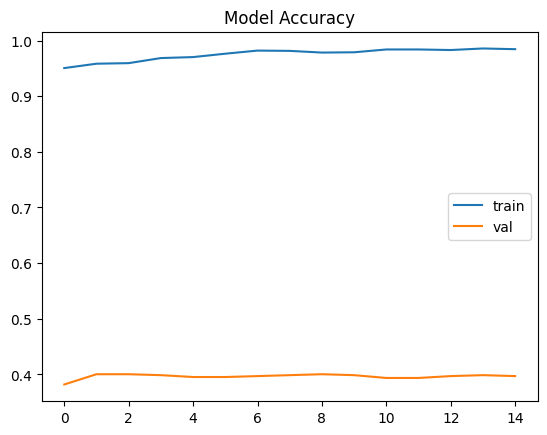

In [23]:
# Training performance
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.legend(["train", "val"])
plt.savefig("accuracy_curve.png")
plt.show()

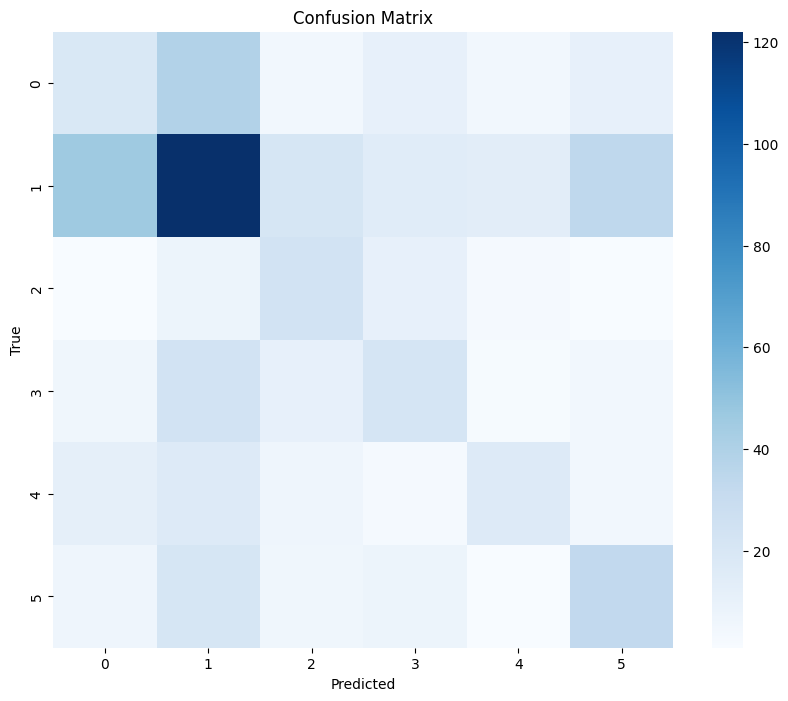

In [24]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png")
plt.show()

## Findings & Conclusions

### Findings

Key findings include:
- The original dataset exhibited significant class imbalance, with some conditions heavily overrepresented compared to others.
- Applying filtering (removing classes with fewer than 100 samples) improved dataset stability and reduced noise from underrepresented classes.
- Oversampling of minority classes helped reduce bias toward dominant conditions such as eczema.
- Data augmentation (rotation, flipping, brightness, and contrast adjustments) improved the model’s ability to generalize to unseen images.
- Transfer learning using DenseNet121 significantly improved feature extraction performance compared to training a model from scratch.
- The final model achieved strong performance on the test set, with overall classification accuracy showing that the model can learn meaningful patterns from clinical image data.


### Conclusions

This project demonstrates the effectiveness of deep learning and transfer learning for multi-class skin condition classification using real-world clinical image data.

The DenseNet121-based model was able to successfully learn discriminative features across multiple skin conditions despite challenges such as class imbalance and variability in image quality.

However, several limitations remain:
- Skin conditions with visually similar features were more frequently misclassified.
- Performance is dependent on dataset quality and diversity.
- The model is not intended for clinical diagnosis and should not be used in real-world medical decision-making.

### Future Work

Future improvements could include:
- Incorporating additional datasets to improve class diversity and reduce bias.
- Exploring more advanced architectures such as EfficientNet or Vision Transformers (ViTs).
- Using advanced imbalance handling techniques such as focal loss.
- Expanding the model into a multi-modal system (combining image & patient metadata).

## Saving The Model

In [ ]:
# Save model
model.save("/content/SCIN_model_DenseNet.keras")

In [ ]:
# Save labels
label_map = dict(enumerate(class_names))

import json
with open("SCIN_labels_DenseNet.json", "w") as f:
    json.dump(label_map, f)

In [ ]:
# Download
from google.colab import files
files.download("/content/SCIN_model_DenseNet.keras")

from google.colab import files
files.download("SCIN_labels_DenseNet.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>